# Causal Inference and Experimentation
## A/B Testing, Causal Effects, and Experimental Design

This notebook covers key concepts in causal inference and experimentation:
- A/B test simulation and statistical analysis
- Propensity score matching for observational studies
- Simpson's paradox and confounding
- Difference-in-differences (DiD) methodology
- Uplift modeling
- Power analysis and sample size calculation
- Multiple testing corrections

📺 **Video Lecture:** [https://youtu.be/J4_3yDvDvL0](https://youtu.be/J4_3yDvDvL0)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import comb
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. A/B Test Simulation and Analysis

Simulate a simple A/B test where we randomly assign users to control and treatment groups.

In [3]:
# Simulate A/B test
n_control = 5000
n_treatment = 5000
true_control_rate = 0.10  # 10% conversion in control
true_treatment_rate = 0.12  # 12% conversion in treatment

# Generate data
control_conversions = np.random.binomial(1, true_control_rate, n_control)
treatment_conversions = np.random.binomial(1, true_treatment_rate, n_treatment)

# Calculate statistics
control_mean = control_conversions.mean()
treatment_mean = treatment_conversions.mean()
control_se = np.sqrt(control_mean * (1 - control_mean) / n_control)
treatment_se = np.sqrt(treatment_mean * (1 - treatment_mean) / n_treatment)

# Perform t-test
t_stat, p_value = stats.ttest_ind(treatment_conversions, control_conversions)

print(f"Control Conversion Rate: {control_mean:.4f} (SE: {control_se:.4f})")
print(f"Treatment Conversion Rate: {treatment_mean:.4f} (SE: {treatment_se:.4f})")
print(f"Absolute Lift: {(treatment_mean - control_mean):.4f}")
print(f"Relative Lift: {((treatment_mean - control_mean) / control_mean * 100):.2f}%")
print(f"\nt-test p-value: {p_value:.4f}")
print(f"Statistically significant at α=0.05: {p_value < 0.05}")

Control Conversion Rate: 0.0958 (SE: 0.0042)
Treatment Conversion Rate: 0.1134 (SE: 0.0045)
Absolute Lift: 0.0176
Relative Lift: 18.37%

t-test p-value: 0.0040
Statistically significant at α=0.05: True


## 2. Confidence Intervals for A/B Test Results

Control 95% CI: [0.0876, 0.1040]
Treatment 95% CI: [0.1046, 0.1222]
Lift 95% CI: [0.0056, 0.0296]


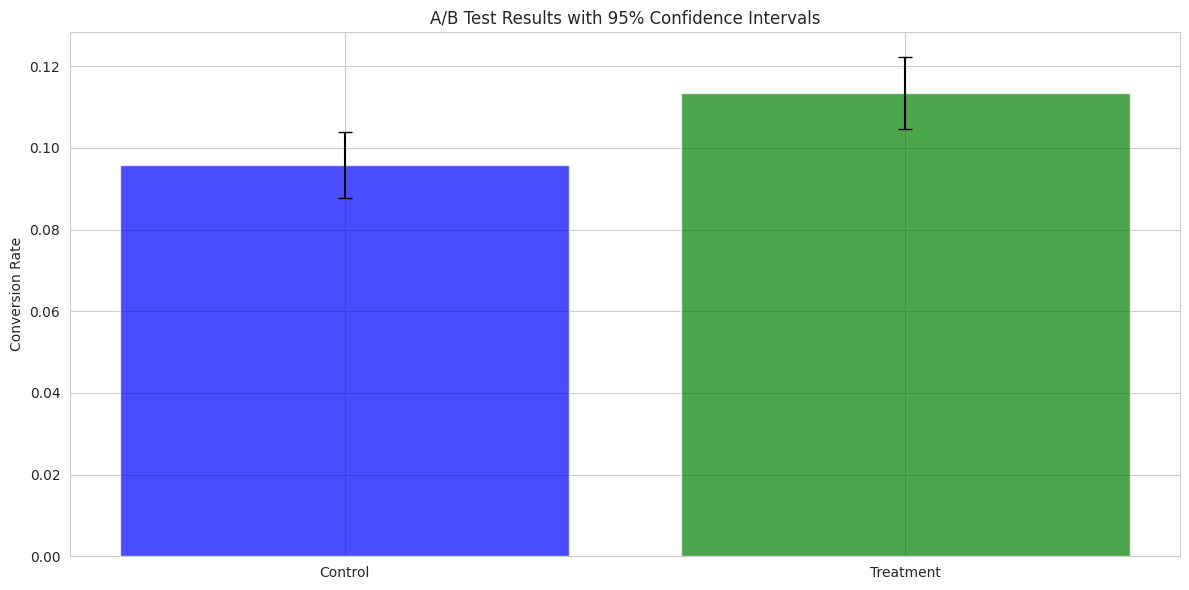

In [4]:
# Calculate 95% confidence intervals
z_critical = 1.96  # 95% CI

control_ci = [
    control_mean - z_critical * control_se,
    control_mean + z_critical * control_se
]
treatment_ci = [
    treatment_mean - z_critical * treatment_se,
    treatment_mean + z_critical * treatment_se
]

# Lift CI
lift = treatment_mean - control_mean
lift_se = np.sqrt(control_se**2 + treatment_se**2)
lift_ci = [
    lift - z_critical * lift_se,
    lift + z_critical * lift_se
]

print(f"Control 95% CI: [{control_ci[0]:.4f}, {control_ci[1]:.4f}]")
print(f"Treatment 95% CI: [{treatment_ci[0]:.4f}, {treatment_ci[1]:.4f}]")
print(f"Lift 95% CI: [{lift_ci[0]:.4f}, {lift_ci[1]:.4f}]")

# Visualization
fig, ax = plt.subplots()
groups = ['Control', 'Treatment']
means = [control_mean, treatment_mean]
errors = [control_se, treatment_se]

ax.bar(groups, means, yerr=[z_critical * e for e in errors], capsize=5, alpha=0.7, color=['blue', 'green'])
ax.set_ylabel('Conversion Rate')
ax.set_title('A/B Test Results with 95% Confidence Intervals')
plt.tight_layout()
plt.show()

## 3. Simpson's Paradox Demonstration

A phenomenon where a trend reverses when data is aggregated vs. stratified.

In [5]:
# Simpson's Paradox: Drug A appears better overall but worse in each subgroup
data = {
    'Group': ['Drug A', 'Drug A', 'Drug B', 'Drug B', 'Drug A', 'Drug A', 'Drug B', 'Drug B'],
    'Severity': ['Low', 'Low', 'Low', 'Low', 'High', 'High', 'High', 'High'],
    'Recovered': [81, 81, 234, 234, 6, 6, 48, 48],
    'Total': [87, 87, 270, 270, 10, 10, 52, 52]
}

df = pd.DataFrame(data)
df['Recovery_Rate'] = (df['Recovered'] / df['Total'] * 100).round(2)

print("Simpson's Paradox Example:")
print(df[['Group', 'Severity', 'Recovery_Rate']])

# Aggregate
agg = df.groupby('Group').agg({'Recovered': 'sum', 'Total': 'sum'})
agg['Recovery_Rate'] = (agg['Recovered'] / agg['Total'] * 100).round(2)
print("\nAggregate Recovery Rates:")
print(agg[['Recovery_Rate']])

print("\nNotice: Drug A is better overall, but Drug B is better in BOTH severity groups!")

Simpson's Paradox Example:
    Group Severity  Recovery_Rate
0  Drug A      Low          93.10
1  Drug A      Low          93.10
2  Drug B      Low          86.67
3  Drug B      Low          86.67
4  Drug A     High          60.00
5  Drug A     High          60.00
6  Drug B     High          92.31
7  Drug B     High          92.31

Aggregate Recovery Rates:
        Recovery_Rate
Group                
Drug A          89.69
Drug B          87.58

Notice: Drug A is better overall, but Drug B is better in BOTH severity groups!


## 4. Propensity Score Matching (PSM)

Match treated and control units based on propensity scores to reduce bias in observational studies.

In [6]:
# Generate synthetic observational data with confounding
n = 1000
X1 = np.random.normal(0, 1, n)  # Confounder
X2 = np.random.normal(0, 1, n)  # Another variable

# Treatment assignment depends on confounder (confounding!)
treatment_prob = 1 / (1 + np.exp(-0.5 - 2*X1))
treatment = (np.random.uniform(0, 1, n) < treatment_prob).astype(int)

# Outcome: depends on both treatment and confounder
outcome = 2*treatment + 1.5*X1 + 0.5*X2 + np.random.normal(0, 0.5, n)

# Naive estimate (biased due to confounding)
naive_ate = outcome[treatment == 1].mean() - outcome[treatment == 0].mean()
print(f"Naive ATE (biased): {naive_ate:.4f}")
print(f"True ATE: 2.0000 (treatment effect)")

# Propensity Score Matching
# Estimate propensity scores using logistic regression
from sklearn.linear_model import LogisticRegression
X_data = np.column_stack([X1, X2])
lr = LogisticRegression().fit(X_data, treatment)
propensity_scores = lr.predict_proba(X_data)[:, 1]

# Match treated units to control units with similar propensity scores
treated_idx = np.where(treatment == 1)[0]
control_idx = np.where(treatment == 0)[0]

matched_outcome_diff = []
for t_idx in treated_idx:
    # Find closest control unit by propensity score
    distances = np.abs(propensity_scores[t_idx] - propensity_scores[control_idx])
    closest_control_idx = control_idx[np.argmin(distances)]
    matched_outcome_diff.append(outcome[t_idx] - outcome[closest_control_idx])

psm_ate = np.mean(matched_outcome_diff)
print(f"\nPropensity Score Matching ATE: {psm_ate:.4f}")
print(f"PSM is closer to true effect than naive estimate!")

Naive ATE (biased): 3.9460
True ATE: 2.0000 (treatment effect)

Propensity Score Matching ATE: 2.2564
PSM is closer to true effect than naive estimate!


## 5. Confounding Variable Demonstration

In [7]:
# Create simple confounding scenario
# Age affects both treatment adoption and outcome

n = 500
age = np.random.normal(40, 10, n)  # Age confounder

# Treatment more likely for younger people
treatment_prob = 1 / (1 + np.exp(-0.1 * (age - 40)))
treatment = (np.random.uniform(0, 1, n) < treatment_prob).astype(int)

# Outcome depends on age
outcome = 5 + 0.02*age + 3*treatment + np.random.normal(0, 1, n)

# Confounded comparison
naive_effect = outcome[treatment == 1].mean() - outcome[treatment == 0].mean()

# Control for confounder (stratified analysis)
age_strata = pd.cut(age, bins=5)
df_conf = pd.DataFrame({'age_strata': age_strata, 'treatment': treatment, 'outcome': outcome})
stratified_effects = df_conf.groupby('age_strata').apply(
    lambda x: x[x['treatment'] == 1]['outcome'].mean() - x[x['treatment'] == 0]['outcome'].mean()
)
controlled_effect = stratified_effects.mean()

print(f"Naive Effect (confounded): {naive_effect:.4f}")
print(f"Controlled Effect (adjusted for age): {controlled_effect:.4f}")
print(f"True treatment effect: 3.0000")
print(f"\nControlling for the confounder gives a more accurate estimate!")

Naive Effect (confounded): 2.9927
Controlled Effect (adjusted for age): 2.9770
True treatment effect: 3.0000

Controlling for the confounder gives a more accurate estimate!


## 6. Difference-in-Differences (DiD)

DiD compares trends before and after intervention across treated and control groups.

DiD Table (Average Outcomes):
              Before      After
group                          
control    11.066721  13.541491
treatment  11.008756  15.507442

DiD Estimate of Treatment Effect: 2.0239
True treatment effect: 2.0000


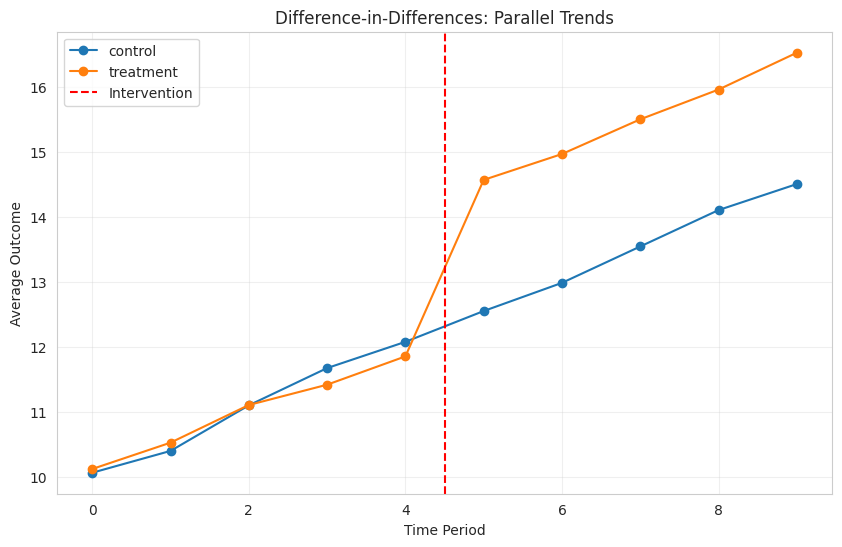

In [8]:
# Generate panel data with intervention at t=5
time_periods = 10
n_units_per_group = 100

data_list = []
for t in range(time_periods):
    for unit in range(n_units_per_group):
        # Control group
        outcome_c = 10 + 0.5*t + np.random.normal(0, 1)
        data_list.append({'time': t, 'unit': unit, 'group': 'control', 'outcome': outcome_c, 'treated': 0})
        
        # Treatment group
        post_intervention = 1 if t >= 5 else 0
        outcome_t = 10 + 0.5*t + 2*post_intervention + np.random.normal(0, 1)
        data_list.append({'time': t, 'unit': unit + n_units_per_group, 'group': 'treatment', 'outcome': outcome_t, 'treated': post_intervention})

df_panel = pd.DataFrame(data_list)

# Calculate average outcomes before/after for each group
did_table = df_panel.groupby(['group', df_panel['time'] >= 5])['outcome'].mean().unstack()
did_table.columns = ['Before', 'After']
print("DiD Table (Average Outcomes):")
print(did_table)

# DiD Estimator = (After_Treated - Before_Treated) - (After_Control - Before_Control)
did_effect = (did_table.loc['treatment', 'After'] - did_table.loc['treatment', 'Before']) - \
             (did_table.loc['control', 'After'] - did_table.loc['control', 'Before'])
print(f"\nDiD Estimate of Treatment Effect: {did_effect:.4f}")
print(f"True treatment effect: 2.0000")

# Visualize
avg_by_group_time = df_panel.groupby(['group', 'time'])['outcome'].mean()
plt.figure(figsize=(10, 6))
for group in ['control', 'treatment']:
    data = avg_by_group_time[group]
    plt.plot(data.index, data.values, marker='o', label=group)
plt.axvline(x=4.5, color='red', linestyle='--', label='Intervention')
plt.xlabel('Time Period')
plt.ylabel('Average Outcome')
plt.title('Difference-in-Differences: Parallel Trends')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Uplift Modeling

Estimate heterogeneous treatment effects - who benefits most from treatment?

Uplift by Customer Value Segment:
value_segment
Low        1.252360
Medium     3.763993
High      13.283426
dtype: float64

Treatment is most effective for high-value customers!


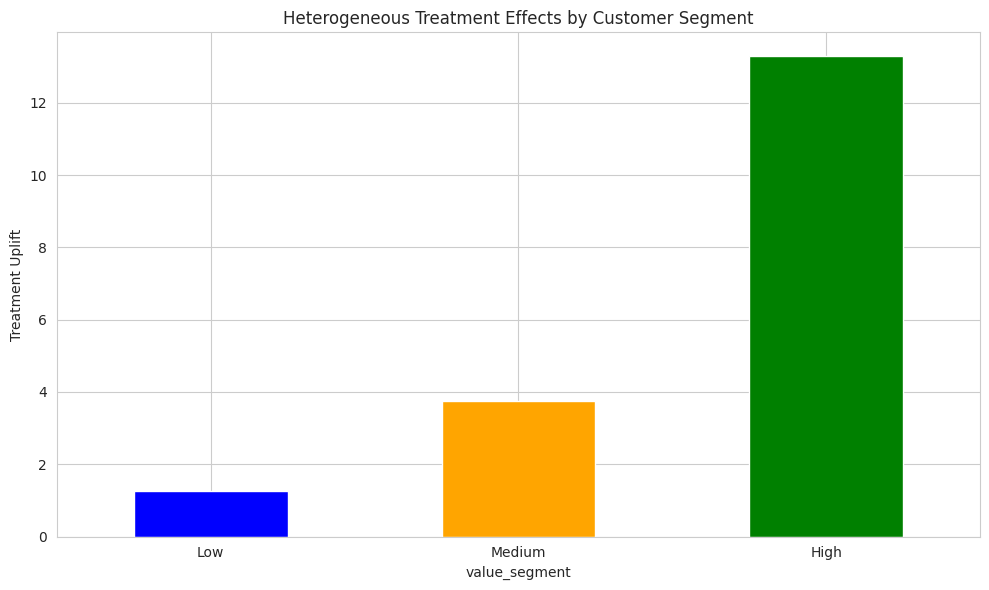

In [9]:
# Generate data where treatment effectiveness depends on customer value
n = 1000
customer_value = np.random.exponential(100, n)  # Customer lifetime value
treatment = np.random.binomial(1, 0.5, n)

# Outcome: treatment works better for high-value customers
baseline = 10 + 0.05 * customer_value
uplift = 5 * (customer_value / 100)  # Heterogeneous effect
outcome = baseline + treatment * uplift + np.random.normal(0, 2, n)

# Simple uplift estimate by value segment
df_uplift = pd.DataFrame({
    'customer_value': customer_value,
    'treatment': treatment,
    'outcome': outcome
})

# Segment by value
df_uplift['value_segment'] = pd.qcut(df_uplift['customer_value'], q=3, labels=['Low', 'Medium', 'High'])

# Calculate segment-level uplift
uplift_by_segment = df_uplift.groupby('value_segment').apply(
    lambda x: x[x['treatment'] == 1]['outcome'].mean() - x[x['treatment'] == 0]['outcome'].mean()
)

print("Uplift by Customer Value Segment:")
print(uplift_by_segment)
print("\nTreatment is most effective for high-value customers!")

plt.figure(figsize=(10, 6))
uplift_by_segment.plot(kind='bar', color=['blue', 'orange', 'green'])
plt.ylabel('Treatment Uplift')
plt.title('Heterogeneous Treatment Effects by Customer Segment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Power Analysis and Sample Size Calculation

Power Analysis Results:
Control rate: 10.00%
Treatment rate: 12.00%
Effect size: 2.00%
Alpha (Type I error): 5.00%
Beta (Type II error): 20.00%
Power: 80.0%

Required sample size per group: 3843
Total sample size needed: 7685


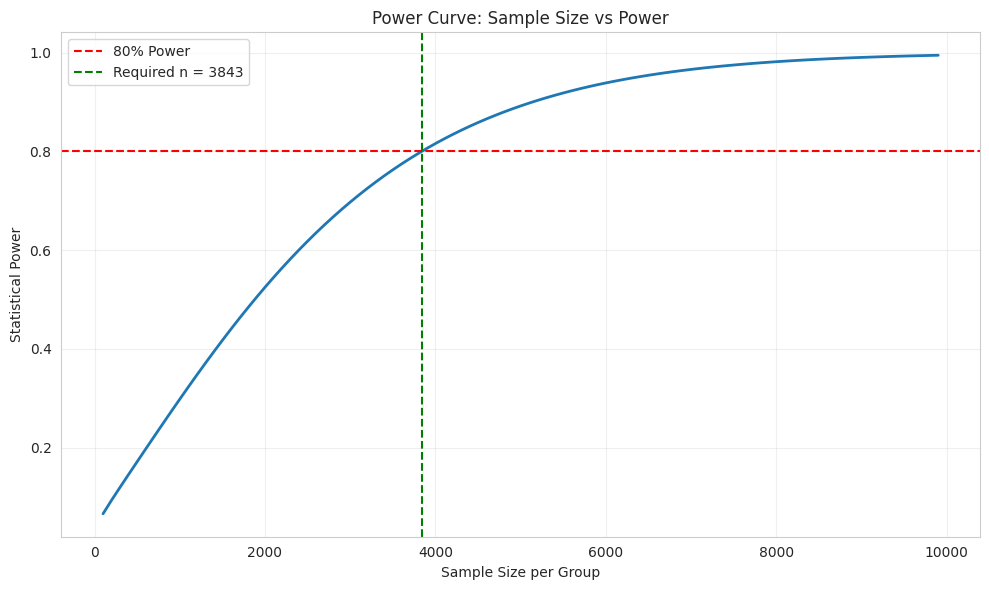

In [10]:
# Power analysis for binary outcomes
# Parameters
alpha = 0.05  # Type I error
beta = 0.2    # Type II error (power = 1 - beta = 0.8)
p_control = 0.10  # Control conversion rate
p_treatment = 0.12  # Treatment conversion rate
effect_size = p_treatment - p_control

# Sample size calculation using normal approximation
z_alpha = stats.norm.ppf(1 - alpha/2)
z_beta = stats.norm.ppf(1 - beta)

p_bar = (p_control + p_treatment) / 2
n_per_group = ((z_alpha + z_beta)**2 * 2 * p_bar * (1 - p_bar)) / (effect_size**2)

print(f"Power Analysis Results:")
print(f"Control rate: {p_control:.2%}")
print(f"Treatment rate: {p_treatment:.2%}")
print(f"Effect size: {effect_size:.2%}")
print(f"Alpha (Type I error): {alpha:.2%}")
print(f"Beta (Type II error): {beta:.2%}")
print(f"Power: {(1-beta):.1%}")
print(f"\nRequired sample size per group: {int(np.ceil(n_per_group))}")
print(f"Total sample size needed: {int(np.ceil(2*n_per_group))}")

# Power curve: how power changes with sample size
sample_sizes = np.arange(100, 10000, 100)
powers = []

for n in sample_sizes:
    se = np.sqrt(2 * p_bar * (1 - p_bar) / n)
    z_critical = stats.norm.ppf(1 - alpha/2)
    z_stat = effect_size / se
    power = 1 - stats.norm.cdf(z_critical - z_stat)
    powers.append(power)

plt.figure(figsize=(10, 6))
plt.plot(sample_sizes, powers, linewidth=2)
plt.axhline(y=0.8, color='red', linestyle='--', label='80% Power')
plt.axvline(x=int(np.ceil(n_per_group)), color='green', linestyle='--', label=f'Required n = {int(np.ceil(n_per_group))}')
plt.xlabel('Sample Size per Group')
plt.ylabel('Statistical Power')
plt.title('Power Curve: Sample Size vs Power')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Multiple Testing Correction

When running multiple tests, we need to control the false positive rate.

Multiple Testing Correction Results (20 tests):

Uncorrected (alpha=0.05):
  Rejections: 5
  False discoveries: 0

Bonferroni Correction (threshold=0.002500):
  Rejections: 1
  False discoveries: 0

Benjamini-Hochberg FDR (threshold=0.0050):
  Rejections: 2
  False discoveries: 0


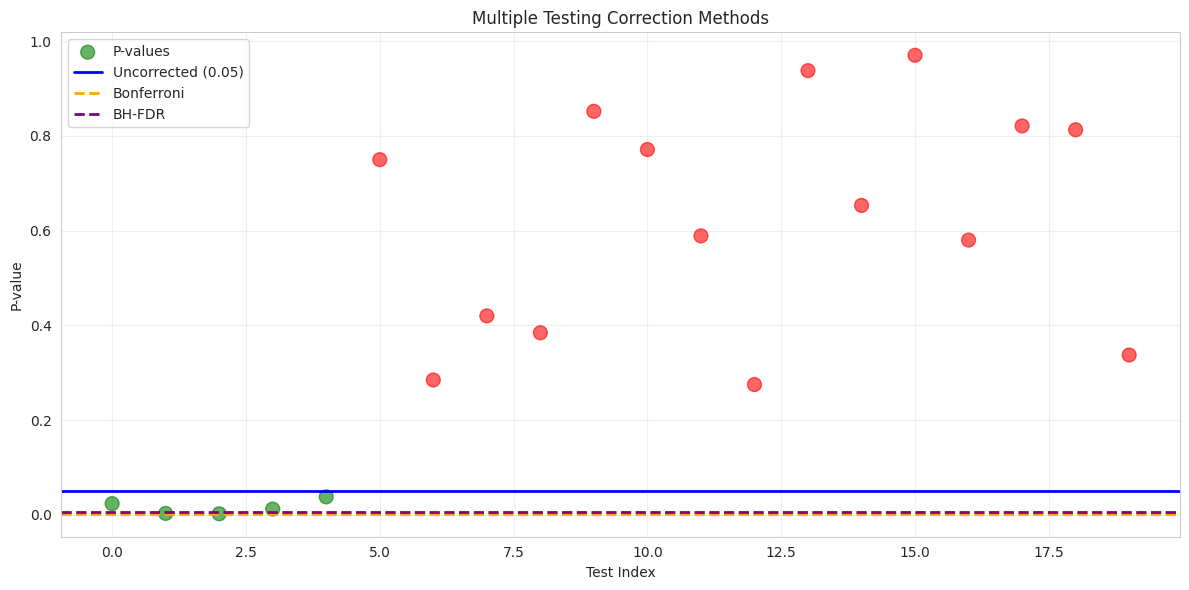

In [11]:
# Simulate multiple hypothesis tests
n_tests = 20
true_effect = np.array([True] * 5 + [False] * 15)  # Only 5 tests have real effect

# Generate p-values
p_values = []
for has_effect in true_effect:
    if has_effect:
        # True positive: effect exists
        p_val = np.random.exponential(0.01)  # Small p-values
    else:
        # Null is true: no effect
        p_val = np.random.uniform(0, 1)  # Uniform distribution
    p_values.append(p_val)

p_values = np.array(p_values)

# Bonferroni correction
bonferroni_threshold = 0.05 / n_tests
bonferroni_reject = p_values < bonferroni_threshold

# Benjamini-Hochberg (FDR) correction
sorted_idx = np.argsort(p_values)
sorted_p = p_values[sorted_idx]
bh_thresholds = 0.05 * np.arange(1, n_tests + 1) / n_tests

# Find the largest i where p[i] <= threshold[i]
bh_threshold = 0
for i in range(n_tests - 1, -1, -1):
    if sorted_p[i] <= bh_thresholds[i]:
        bh_threshold = bh_thresholds[i]
        break

bh_reject = p_values < bh_threshold

print(f"Multiple Testing Correction Results ({n_tests} tests):")
print(f"\nUncorrected (alpha=0.05):")
uncorrected_reject = p_values < 0.05
print(f"  Rejections: {uncorrected_reject.sum()}")
print(f"  False discoveries: {(uncorrected_reject & ~true_effect).sum()}")

print(f"\nBonferroni Correction (threshold={bonferroni_threshold:.6f}):")
print(f"  Rejections: {bonferroni_reject.sum()}")
print(f"  False discoveries: {(bonferroni_reject & ~true_effect).sum()}")

print(f"\nBenjamini-Hochberg FDR (threshold={bh_threshold:.4f}):")
print(f"  Rejections: {bh_reject.sum()}")
print(f"  False discoveries: {(bh_reject & ~true_effect).sum()}")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(n_tests)
colors = ['green' if x else 'red' for x in true_effect]
ax.scatter(x_pos, p_values, c=colors, s=100, alpha=0.6, label='P-values')
ax.axhline(y=0.05, color='blue', linestyle='-', label='Uncorrected (0.05)', linewidth=2)
ax.axhline(y=bonferroni_threshold, color='orange', linestyle='--', label=f'Bonferroni', linewidth=2)
ax.axhline(y=bh_threshold, color='purple', linestyle='--', label=f'BH-FDR', linewidth=2)
ax.set_xlabel('Test Index')
ax.set_ylabel('P-value')
ax.set_title('Multiple Testing Correction Methods')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Summary Table: Key Concepts

Quick reference for causal inference methods and when to use them.

In [12]:
summary_data = {
    'Method': [
        'Randomized Controlled Trial (RCT)',
        'Propensity Score Matching',
        'Stratification/Blocking',
        'Difference-in-Differences',
        'Instrumental Variables',
        'Regression Adjustment',
        'Matching'
    ],
    'Data Type': [
        'Experimental',
        'Observational',
        'Experimental',
        'Panel Data',
        'Observational',
        'Observational',
        'Observational'
    ],
    'Assumptions': [
        'Randomization removes bias',
        'Unconfoundedness, overlap',
        'Known confounders',
        'Parallel trends',
        'Valid instruments',
        'Known confounders, linearity',
        'Overlap, unconfoundedness'
    ],
    'Pros': [
        'Gold standard, unbiased',
        'Removes observed bias',
        'Simple, interpretable',
        'Controls time-invariant confounding',
        'Handles endogeneity',
        'Simple, efficient',
        'Intuitive, removes selection bias'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("CAUSAL INFERENCE METHODS SUMMARY")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)


CAUSAL INFERENCE METHODS SUMMARY
                           Method     Data Type                  Assumptions                                Pros
Randomized Controlled Trial (RCT)  Experimental   Randomization removes bias             Gold standard, unbiased
        Propensity Score Matching Observational    Unconfoundedness, overlap               Removes observed bias
          Stratification/Blocking  Experimental            Known confounders               Simple, interpretable
        Difference-in-Differences    Panel Data              Parallel trends Controls time-invariant confounding
           Instrumental Variables Observational            Valid instruments                 Handles endogeneity
            Regression Adjustment Observational Known confounders, linearity                   Simple, efficient
                         Matching Observational    Overlap, unconfoundedness   Intuitive, removes selection bias


---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>